In [1]:
# === Education.ipynb Cell 1: Setup & activate last run ===

import importlib
import numpy as np

import infra
import embeddings

importlib.reload(infra)
importlib.reload(embeddings)

# Activate last run explicitly (strict: errors if none)
infra.activate_last_run(echo=False)

# Load config + encoder spec for the active run (does not create a new run)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

# Reproducibility (one place only)
SEED = 42
np.random.seed(SEED)

# Read run parameters from config (single source of truth)
YEAR = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("PROJECT_ROOT :", infra.PROJECT_ROOT)
print("RUNS_ROOT    :", infra.RUNS_ROOT)
print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("Exports      :", RP.exports)
print("Cache (run)  :", RP.cache)
print("Cache (glob) :", infra.GLOBAL_CACHE_ROOT)
print("YEAR         :", YEAR)
print("ONET_VERSION :", ONET_VERSION)
print("ENCODER_NAME :", ENCODER_NAME)
print("ENCODER_ID   :", ENCODER_SPEC.embedder_id())
print("SEED         :", SEED)


PROJECT_ROOT : /home/joc/code/occupation-space
RUNS_ROOT    : /home/joc/code/occupation-space/out/runs
RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports      : /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Cache (run)  : /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/cache
Cache (glob) : /home/joc/code/occupation-space/out/_cache
YEAR         : 2025
ONET_VERSION : 30_1
ENCODER_NAME : openai-3-large
ENCODER_ID   : openai:text-embedding-3-large?dim=3072
SEED         : 42


In [2]:
# Cell 2: read tasks/occ from *active* run (RP) + notebook-specific config

from pathlib import Path
import pandas as pd

from infra import RP, read_csv_any, log

# ------------------------------------------------------------------------------
# 1) Notebook-specific config (keep Cell 0 generic)
# ------------------------------------------------------------------------------

P_THRESHOLD = 0.001
TOP_K       = 3
ZONE_RADIUS = {1: 1.0, 2: 2.0, 3: 2.8}  # optional (if plotting zone rings/grid)

DATA_DIR        = Path("../data")
PATH_LABELS     = DATA_DIR / "delRioChanona" / "ipums_labs_mSML_manual.csv"
PATH_MATRIX     = DATA_DIR / "delRioChanona" / "occupational_mobility_network.csv"
XWALK_ONET_SOC6 = DATA_DIR / "nem-onet-to-soc-crosswalk.xlsx"
XWALK_SOC6_ACS  = DATA_DIR / "nem-occcode-acs-crosswalk.xlsx"

# ------------------------------------------------------------------------------
# 2) Resolve exports via infra (active run selection)
# ------------------------------------------------------------------------------

TASK_FILE = RP.export_fp("task_embeddings_polar_scaled.csv")
OCC_FILE  = RP.export_fp("occupation_embeddings_polar_scaled.csv")

log("TASK_FILE:", TASK_FILE)
log("OCC_FILE :", OCC_FILE)

# ------------------------------------------------------------------------------
# 3) Read (limit columns where safe; otherwise read all)
# ------------------------------------------------------------------------------

task_cols = {"onet_code", "Task ID", "Task", "xi", "chi", "is_core"}
occ_cols  = {"onet_code", "Title", "xi", "chi", "sector_zone", "Job Family"}

df_tasks = read_csv_any(
    TASK_FILE,
    usecols=lambda c: c in task_cols,  # robust to extra columns
    dtype={"onet_code": "string", "Task ID": "string"},
)

df_occ = read_csv_any(
    OCC_FILE,
    usecols=lambda c: c in occ_cols,
    dtype={"onet_code": "string", "sector_zone": "string"},
)

# Normalize / types
df_tasks["onet_code"] = df_tasks["onet_code"].astype("string").str.strip()
df_tasks["Task ID"]   = df_tasks["Task ID"].astype("string").str.strip()
df_tasks["xi"]        = pd.to_numeric(df_tasks["xi"], errors="coerce")
df_tasks["chi"]       = pd.to_numeric(df_tasks["chi"], errors="coerce")
if "is_core" in df_tasks.columns:
    df_tasks["is_core"] = df_tasks["is_core"].map(
        lambda x: bool(int(x)) if str(x).isdigit() else bool(x)
    )

df_occ["onet_code"] = df_occ["onet_code"].astype("string").str.strip()
if "sector_zone" in df_occ.columns:
    df_occ["sector_zone"] = df_occ["sector_zone"].astype("string").str.strip()
df_occ["xi"] = pd.to_numeric(df_occ["xi"], errors="coerce")
df_occ["chi"] = pd.to_numeric(df_occ["chi"], errors="coerce")

log("df_tasks:", df_tasks.shape)
log("df_occ  :", df_occ.shape)


• TASK_FILE: /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/task_embeddings_polar_scaled.csv
• OCC_FILE : /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/occupation_embeddings_polar_scaled.csv
• df_tasks: (17606, 6)
• df_occ  : (878, 6)


• RLE coverage tasks: 17606 / 17606
• RLE coverage occ  : 878 / 878


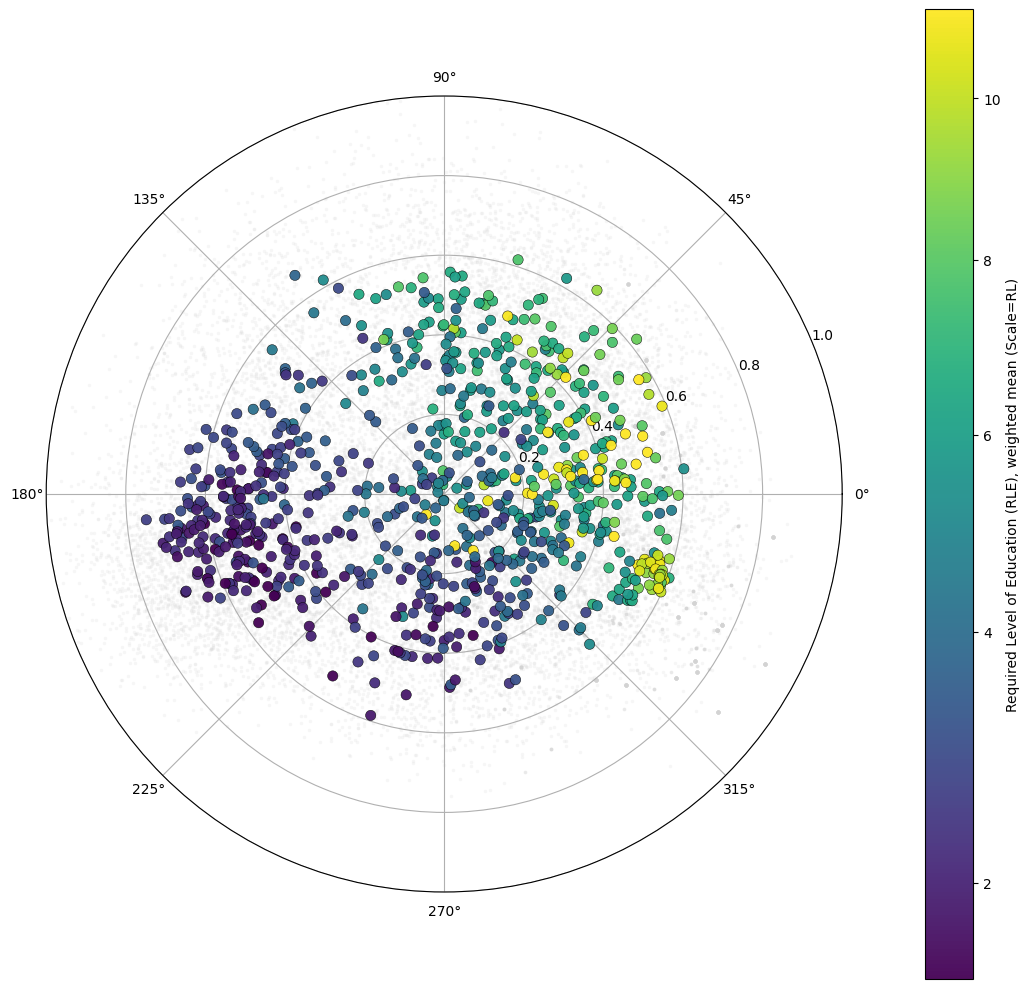

• Saved: /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/plot_rle_overlay.png /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/plot_rle_overlay.pdf /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/rle_overlay_occupations.csv /home/joc/code/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/rle_overlay_tasks.csv


In [4]:
# === Cell 3: RLE via onet.transforms + overlay plot + exports ===========

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import onet
from infra import RP, log, write_csv

# --- Contract (minimal) ---
for name, df, req in [
    ("df_tasks", df_tasks, {"onet_code", "xi", "chi"}),
    ("df_occ",   df_occ,   {"onet_code", "xi", "chi", "Title", "Job Family"}),
]:
    miss = sorted(req - set(df.columns))
    if miss:
        raise ValueError(f"{name} saknar kolumner: {miss}")
    df["onet_code"] = df["onet_code"].astype("string").str.strip()
    df["xi"] = pd.to_numeric(df["xi"], errors="coerce")
    df["chi"] = pd.to_numeric(df["chi"], errors="coerce")

# --- A) O*NET RLE (Required Level of Education; weighted mean) ---
db = onet.get_db(version=ONET_VERSION)
rle = onet.transforms.load_rle(db)   # columns: onet_code, rle_mean
rle["onet_code"] = rle["onet_code"].astype("string").str.strip()
rle["rle_mean"]  = pd.to_numeric(rle["rle_mean"], errors="coerce")

# --- B) Attach RLE ---
tasks_rle = df_tasks.merge(rle, on="onet_code", how="left")
occ_rle   = df_occ.merge(rle,   on="onet_code", how="left")

mask_t = tasks_rle["rle_mean"].notna().to_numpy()
mask_o = occ_rle["rle_mean"].notna().to_numpy()
chi_max = float(max(df_tasks["chi"].max(), df_occ["chi"].max()))

log("RLE coverage tasks:", int(mask_t.sum()), "/", int(len(tasks_rle)))
log("RLE coverage occ  :", int(mask_o.sum()), "/", int(len(occ_rle)))

# --- C) Plot (occupations colored by rle_mean; tasks as gray background) ---
fig, ax = plt.subplots(figsize=(11, 10), subplot_kw={"projection": "polar"})

# Tasks: faint gray background (all tasks)
ax.scatter(tasks_rle["xi"], tasks_rle["chi"],
           s=6, c="lightgray", alpha=0.20, linewidths=0, zorder=0)

# Occupations: colored by rle_mean (only where available)
import matplotlib.colors as mcolors

vals = occ_rle.loc[mask_o, "rle_mean"].to_numpy(float)

# 1) robust min/max (percentiler)
vmin, vmax = np.nanpercentile(vals, [2, 98])

# 2) icke-linjär stretch (gamma < 1 ger mer kontrast i högre nivåer; >1 i lägre)
norm = mcolors.PowerNorm(gamma=0.75, vmin=vmin, vmax=vmax)

sc = ax.scatter(
    occ_rle.loc[mask_o, "xi"], occ_rle.loc[mask_o, "chi"],
    s=55,
    c=vals,
    cmap="viridis",
    norm=norm,
    edgecolors="black", linewidths=0.35, alpha=0.95, zorder=3
)

cb = fig.colorbar(sc, ax=ax, pad=0.08)
cb.set_label("Required Level of Education (RLE), weighted mean (Scale=RL)")

ax.set_ylim(0, chi_max)
ax.grid(True)
plt.tight_layout()

png = RP.figure_fp("plot_rle_overlay.png")
pdf = RP.figure_fp("plot_rle_overlay.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, dpi=300, bbox_inches="tight")
plt.show()

# --- D) Export (joined frames) ---
occ_out = occ_rle.copy()
tasks_out = tasks_rle.merge(
    df_occ[["onet_code", "Title", "Job Family"]],
    on="onet_code", how="left", validate="m:1"
)

write_csv(RP.export_fp("rle_overlay_occupations.csv"), occ_out,   index=False)
write_csv(RP.export_fp("rle_overlay_tasks.csv"),       tasks_out, index=False)

log("Saved:", png, pdf, RP.export_fp("rle_overlay_occupations.csv"), RP.export_fp("rle_overlay_tasks.csv"))
